In [62]:
# Libraries
import os
import pandas as pd
import numpy as np

# Imports for model building
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout

# Imports for image transformations
from tensorflow.keras.layers import RandomFlip
from tensorflow.keras.layers import RandomZoom
from tensorflow.keras.layers import RandomRotation
from tensorflow.keras.layers import RandomTranslation

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Importing Keras utility for image dataset loading
from keras.utils import image_dataset_from_directory

# Reporting t
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from imblearn.metrics import classification_report_imbalanced

# Imports for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# Use this cell, whenever a change was made to the helper functions
# and the library needs to be reloaded in order to take effect
import helper
import importlib
importlib.reload(helper)

<module 'helper' from '/Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/notebooks/helper.py'>

In [27]:
# Variables and definitions
COVID_FOLDER = 'COVID-19_Radiography_Dataset'
#class_normal = 'normal'
#class_lung_opacity = 'lung_opacity'
#class_viral_pneumonia = 'viral_pneumonia'
#class_covid = 'covid'

### First try with Transfer Learning

##### Dataset loading and preprocessing

In [56]:
def read_xray_images(folder_path):
    batch_size = 16 # Rather small for fine grained learning rate
    input_shape = (224,224) # Resize it implicitely for our model

    # Load the dataset with validation split
    train_ds, val_ds = image_dataset_from_directory(
        folder_path,
        label_mode="int",      # for sparse_categorical_entropy training
        batch_size=batch_size,
        image_size=input_shape,
        validation_split=0.2,  # 20% for validation
        subset="both",         # Specify subset for training and validation to be created
        seed=42                # Ensure reproducibility
    )

    # Check, which class names found (should be our 4 (or less for trials)) and save it for later use
    class_names = train_ds.class_names.copy()
    print('Found classes:', class_names)

    # Optionally, you can cache and prefetch for performance
    train_ds = train_ds.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    val_ds = val_ds.cache().prefetch(buffer_size=tf.data.experimental.AUTOTUNE)

    # Verify the datasets
    for images, labels in train_ds.take(1):
        print("Train dataset batch:", images.shape, labels.shape)
        print('Labels', labels.numpy())

    for images, labels in val_ds.take(1):
        print("Validation dataset batch:", images.shape, labels.shape)
        print('Labels', labels.numpy())

    return train_ds, val_ds, class_names

In [79]:
# Manually gather only the 'images' subfolders for each class
# in order to do this, we must temporarily move the masks away from the images
TMP_FOLDER = 'tmp_' + str(np.random.randint(1e9))
MASK_FOLDER = 'masks'

# Parent folder
parent_folder = os.path.dirname(os.getcwd())
# COVID-19_Radiography_Dataset folder
folder_path = os.path.join(parent_folder, COVID_FOLDER)
tmp_folder_path = os.path.join(parent_folder, TMP_FOLDER)

# Prepare to move each masks subfolder temporarily away
folder_moves_dict = {os.path.join(folder_path, class_name, MASK_FOLDER):
                      os.path.join(parent_folder, TMP_FOLDER, class_name, MASK_FOLDER)
               for class_name in os.listdir(folder_path) 
               if os.path.isdir(os.path.join(folder_path, class_name, MASK_FOLDER))}

# Check if tmp-folder exists and create if not
tmp_exists = os.path.isdir(tmp_folder_path)
if False == tmp_exists:
   os.makedirs(tmp_folder_path, exist_ok=True)
   print(f"Created empty directory: {tmp_folder_path}")

# Move away the masks to tmp-folder
for move_from, move_to in folder_moves_dict.items():
   # Move the entire directory (actually by just renaming)
   os.makedirs(move_to, exist_ok=True)
   os.rename(move_from, move_to)
   print(f"Moved {move_from} to {move_to}")

# Read in the images
train_ds, val_ds, class_names = read_xray_images(folder_path)

# Move back the masks again and clean the tmp-folder
for move_to, move_from in folder_moves_dict.items(): # reverse order!
   # Move the entire directory
   os.rename(move_from, move_to)
   print(f"Moved {move_from} to {move_to}")

# If the tmp folder hasn't existed before, delete it again
if False == tmp_exists: # it hasn't existed before
   for dir in os.listdir(tmp_folder_path):
      os.rmdir(os.path.join(tmp_folder_path,dir))
   os.rmdir(tmp_folder_path)
   print(f"Deleted empty directory: {tmp_folder_path}")

Created empty directory: /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/tmp_66415527
Moved /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/Viral Pneumonia/masks to /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/tmp_66415527/Viral Pneumonia/masks
Moved /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/Lung_Opacity/masks to /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/tmp_66415527/Lung_Opacity/masks
Moved /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/Normal/masks to /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/tmp_66415527/Normal/masks
Moved /Users/markusfuchs/Development/Machine Learning Engineer/Covid-19_detection/COVID-19_Radiography_Dataset/COVID/masks to /Users/markusfuchs/Development/Machine Lear

2025-03-14 18:39:13.779075: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-03-14 18:39:13.787539: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-03-14 18:39:13.843122: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

In [ ]:
# Number of batches in the training dataset
print("Number of batch in train_ds:", train_ds.cardinality().numpy())

# Number of batches in the validation dataset
print("Number of batch in val_ds:", val_ds.cardinality().numpy())

# Let's check compatible input format for VGG16
for images, labels in train_ds.take(1):
    print(images.shape, labels.shape)
    for image, label in zip(images.numpy(),labels.numpy()):
        print(image.shape, label)

Number of batch in train_ds: 1059
Number of batch in val_ds: 265
(16, 224, 224, 3) (16,)
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 3
(224, 224, 3) 2
(224, 224, 3) 0
(224, 224, 3) 2
(224, 224, 3) 1
(224, 224, 3) 1
(224, 224, 3) 0
(224, 224, 3) 0
(224, 224, 3) 1
(224, 224, 3) 2
(224, 224, 3) 0


2025-03-14 18:40:34.946798: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2025-03-14 18:40:34.957306: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# We have imbalanced data, hence let's calculate class_weights to give it the model
from collections import Counter

# Count occurrences of each class
class_counts = Counter()
total_count = 0
for images, labels in train_ds:
    for label in labels.numpy():  # Convert tensor to numpy
        class_counts[label] += 1
        total_count += 1

# Convert label indices to class names
class_counts_named = {class_names[idx]: count for idx, count in class_counts.items()}
print("Class Counts:", class_counts_named)

class_weights_dict = { class_label: total_count / (len(class_counts) * class_counts[class_label])
                 for class_label, class_count in class_counts.items() }
print('Class Weights:', class_weights_dict)

Class Counts: {'Normal': 8134, 'COVID': 2903, 'Lung_Opacity': 4847, 'Viral Pneumonia': 1048}
Class Weights: {2: 0.5204081632653061, 0: 1.4581467447468137, 1: 0.8733237053847741, 3: 4.03912213740458}


2025-03-14 18:41:32.173647: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [84]:
# Preprocessing for pretrained models in the same way
# the preprocessor comes with the pretrained model library
from tensorflow.keras.applications.vgg16 import preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

#### Try with VGG16 (imagenet pretrained)

In [89]:
# This model name for saving and loading
model_name = 'vgg16_' + str(len(class_names)) + '-classes.keras'

In [85]:
# Imports for using a pre-trained model
from tensorflow.keras.applications.vgg16 import VGG16

# VGG16 model
base_model = VGG16(weights='imagenet', include_top=False)

# Freeze the layers of VGG16
base_model.trainable = False

# Model creation using the Functional API
inputs = Input(shape=(224, 224, 3))

# Apply augmentations
#x = RandomRotation(0.1)(inputs)
#x = RandomTranslation(height_factor=0.1, width_factor=0.1)(x)
#x = RandomZoom(0.1)(x)
#x = RandomFlip("horizontal")(x)

# Build the model
x = base_model(inputs)
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(rate=0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(rate=0.2)(x)
outputs = Dense(len(class_names), activation='softmax')(x)

vgg16 = Model(inputs=inputs, outputs=outputs)

In [86]:
# Applied Callbacks
early_stopping = EarlyStopping(
                                patience=3, # Wait for 5 epochs before applying
                                min_delta=0.01, # If the loss function doesn't change by 1% after 3 epochs, either up or down, we stop
                                verbose=1, # Display the epoch at which training stops
                                mode='min',
                                monitor='val_loss')

# A learning rate reduction callback to reduce the learning rate when the validation loss stagnates
reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # If val_loss stagnates for 3 consecutive epochs based on the min_delta value
                                    min_delta=0.01,
                                    factor=0.1,  # Reduce the learning rate by a factor of 0.1
                                    cooldown=3,  # Wait 3 epochs before retrying
                                    verbose=1)

In [87]:
# Compile with first idea of appropriate parameters
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

# Print how it looks like
vgg16.summary()

# Convert summary to DataFrame and display it (for copy and paste purposes)
from helper import model_summary_to_df
df_summary = model_summary_to_df(vgg16)
display(df_summary)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,766,852 (60.15 MB)

 Trainable params: 1,052,164 (4.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

,Layer Name (type),Output Shape,Param Count
0,input_layer_1 (InputLayer),"(None, 224, 224, 3)",0
1,vgg16 (Functional),"(None, 7, 7, 512)","14,714,688"
2,global_average_pooling2d,"(None, 512)",0
3,(GlobalAveragePooling2D),,
4,dense (Dense),"(None, 1024)","525,312"
5,dropout (Dropout),"(None, 1024)",0
6,dense_1 (Dense),"(None, 512)","524,800"
7,dropout_1 (Dropout),"(None, 512)",0
8,dense_2 (Dense),"(None, 4)","2,052"


In [ ]:
# Train it with the entire dataset (takes very long!)
history_model = vgg16.fit(train_ds,
                          epochs=10,
                          validation_data=val_ds,
                          class_weight=class_weights_dict,
                          callbacks=[early_stopping, reduce_learning_rate])

# For a first quick evaluation, just read in a few batches instead of the entire dataset
#nr_batches = 16
#history_model = vgg16.fit(train_ds.shuffle(1000).take(nr_batches), 
#                          epochs=10,
#                          validation_data=val_ds.shuffle(1000).take(nr_batches),
#                          class_weight=class_weights_dict)

Epoch 1/10


2025-03-14 18:50:34.575756: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 169 of 1000
2025-03-14 18:50:44.588424: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 303 of 1000
2025-03-14 18:51:04.477428: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 620 of 1000
2025-03-14 18:51:14.502075: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 780 of 1000
2025-03-14 18:51:32.571795: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.3571 - loss: 4.5683

2025-03-14 18:53:54.015521: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1013: Filling up shuffle buffer (this may take a while): 196 of 1000
2025-03-14 18:54:01.896221: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


16/16 ━━━━━━━━━━━━━━━━━━━━ 323s 16s/step - accuracy: 0.3620 - loss: 4.4759 - val_accuracy: 0.5547 - val_loss: 2.0905
Epoch 2/10


...

16/16 ━━━━━━━━━━━━━━━━━━━━ 317s 15s/step - accuracy: 0.7578 - loss: 0.5099 - val_accuracy: 0.7305 - val_loss: 1.0081
Epoch 10/10


2025-03-14 19:47:31.773178: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 129 of 1000
2025-03-14 19:47:41.791711: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 225 of 1000
2025-03-14 19:47:52.078615: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 337 of 1000
2025-03-14 19:48:11.890830: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 505 of 1000
2025-03-14 19:48:23.448876: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this may take a while): 570 of 1000
2025-03-14 19:48:41.847860: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1011: Filling up shuffle buffer (this

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7629 - loss: 0.6835

2025-03-14 19:51:56.760599: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1013: Filling up shuffle buffer (this may take a while): 138 of 1000
2025-03-14 19:52:06.904067: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:450] ShuffleDatasetV3:1013: Filling up shuffle buffer (this may take a while): 233 of 1000
2025-03-14 19:52:09.953614: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:480] Shuffle buffer filled.


16/16 ━━━━━━━━━━━━━━━━━━━━ 391s 15s/step - accuracy: 0.7607 - loss: 0.6848 - val_accuracy: 0.4023 - val_loss: 1.6035


In [91]:
# Save the model for potential later use
vgg16.save(model_name)

##### Evalution

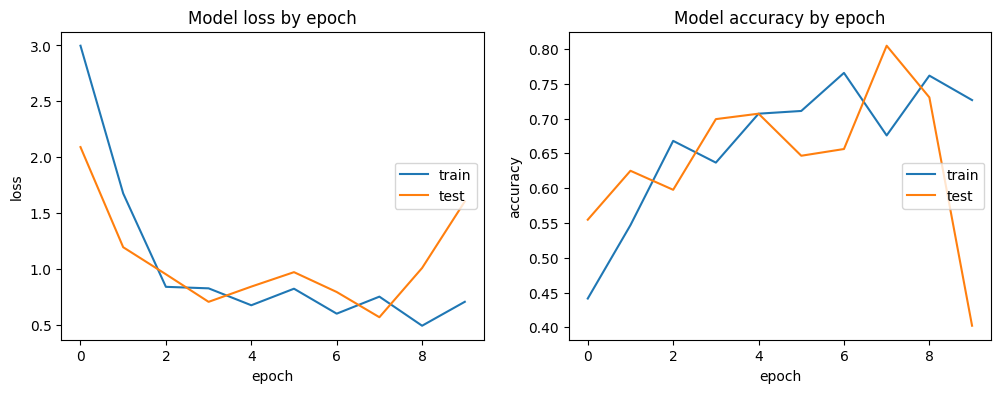

In [92]:
from helper import plot_learning_curve
plot_learning_curve(history_model)

> We can see, that our model accuracy stagnates at appr. 70%
> It seems, that we cannot improve here much.

In [93]:
from tensorflow import keras
vgg16 = keras.models.load_model(model_name)

In [ ]:
from helper import get_predictions_and_labels
#y_true, y_pred = get_predictions_and_labels(vgg16, val_ds.take(8)) # for a quick result
y_true, y_pred = get_predictions_and_labels(vgg16, val_ds)

2025-03-14 19:57:42.634812: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,pre,rec,spe,f1,geo,iba,sup
COVID,0.297619,1.000000,0.427184,0.458716,0.653594,0.451654,25.000000
Lung_Opacity,1.000000,0.241379,1.000000,0.388889,0.491304,0.223068,29.000000
Normal,1.000000,0.242424,1.000000,0.390244,0.492366,0.224059,66.000000
Viral Pneumonia,0.380952,1.000000,0.891667,0.551724,0.944281,0.901326,8.000000
avg_pre,0.824126,0.824126,0.824126,0.824126,0.824126,0.824126,0.824126
avg_rec,0.437500,0.437500,0.437500,0.437500,0.437500,0.437500,0.437500
avg_spe,0.881351,0.881351,0.881351,0.881351,0.881351,0.881351,0.881351
avg_f1,0.413403,0.413403,0.413403,0.413403,0.413403,0.413403,0.413403
avg_geo,0.551860,0.551860,0.551860,0.551860,0.551860,0.551860,0.551860
avg_iba,0.310616,0.310616,0.310616,0.310616,0.310616,0.310616,0.310616


Predicted,COVID,Lung_Opacity,Normal,Viral Pneumonia
COVID,25,0,0,0
Lung_Opacity,18,7,0,4
Normal,41,0,16,9
Viral Pneumonia,0,0,0,8


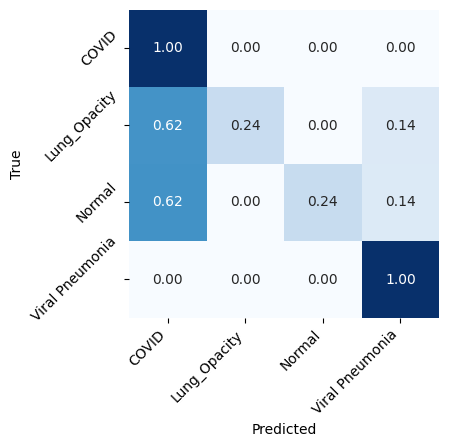

{'crosstab': Predicted        COVID  Lung_Opacity  Normal  Viral Pneumonia
 COVID               25             0       0                0
 Lung_Opacity        18             7       0                4
 Normal              41             0      16                9
 Viral Pneumonia      0             0       0                8,
 'classification_report':                         pre         rec         spe          f1         geo  \
 COVID              0.297619    1.000000    0.427184    0.458716    0.653594   
 Lung_Opacity       1.000000    0.241379    1.000000    0.388889    0.491304   
 Normal             1.000000    0.242424    1.000000    0.390244    0.492366   
 Viral Pneumonia    0.380952    1.000000    0.891667    0.551724    0.944281   
 avg_pre            0.824126    0.824126    0.824126    0.824126    0.824126   
 avg_rec            0.437500    0.437500    0.437500    0.437500    0.437500   
 avg_spe            0.881351    0.881351    0.881351    0.881351    0.881351   
 avg_f1

In [96]:
from helper import report_model_performance
report_model_performance(y_true, y_pred, class_names)

# Conclusion: Our model predicts the 4 classes already not too bad
# However, the recall especially for the covid class is the lowest